# House Price Prediction — Data Preprocessing
This notebook covers the second phase of the project — cleaning and preparing the dataset
for model building based on the issues identified during EDA.

### **Steps:**
1. Fix Data Types
2. Handle Missing Values
3. Handle Outliers
4. Fix Skewed Features
5. Feature Engineering
6. Encoding
7. Save Cleaned Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('../data/AmesHousing.csv')

# rename to match train.csv convention (remove spaces, fix names)
df = df.rename(columns={
    col: col.replace(' ', '').replace('/', '') 
    for col in df.columns
})

# specific fixes
df = df.rename(columns={
    'MSSubClass': 'MSSubClass',  # already fine after space removal
    'YearRemodAdd': 'YearRemodAdd',  # Year Remod/Add -> YearRemodAdd (slash removed)
    'Order': 'Id',  # use Order as Id equivalent
})

df = df.drop(columns=['PID'], errors='ignore')

print(df.shape)
print(df.columns.tolist())

(2930, 81)
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea

## 1. Fix Data Types
From EDA we identified the following dtype issues:

| Column | Current Type | Correct Type | Reason |
|---|---|---|---|
| `GarageYrBlt` | float64 | int64 | Year stored as float due to missing values |
| `LotFrontage` | float64 | int64 | Linear feet stored as float due to missing values |
| `MasVnrArea` | float64 | int64 | Area stored as float due to missing values |
| `MoSold` | int64 | object | Month is categorical, not truly numerical |

Note: Float → Int conversions will be done **after** filling missing values,
since pandas cannot convert a float column with nulls to int directly.

In [3]:
df['GarageYrBlt'].fillna(df['YearBuilt']) # Preview Only
df['GarageYrBlt']

0       1960.0
1       1961.0
2       1958.0
3       1968.0
4       1997.0
         ...  
2925    1984.0
2926    1983.0
2927       NaN
2928    1975.0
2929    1993.0
Name: GarageYrBlt, Length: 2930, dtype: float64

We considered two reasonable strategies for imputing missing values in `GarageYrBlt`:

1. Replace missing values with the median of the `GarageYrBlt` column  
2. Replace missing values with the corresponding `YearBuilt` value for each house  

We chose the second approach because it is more context-aware. In many cases, the garage is likely to have been constructed at the same time as the house, so using `YearBuilt` preserves a plausible relationship between the two features. By contrast, median imputation would ignore property-specific information and could introduce less realistic values.

In [4]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(df['YearBuilt'])
df['GarageYrBlt'] = df['GarageYrBlt'].astype(int)
df['GarageYrBlt'].isnull().sum()

0

Successfully changed the data type from float to int for `GarageYrBlt` and imputed for missing values. We will do it for `LotFrontage` and `MasVnrArea` now.

In [5]:
print(f'Skewness for \'LotFrontage\': {df['LotFrontage'].skew()}')

Skewness for 'LotFrontage': 1.499067354883421


Before imputing missing values in `LotFrontage`, I examined the distribution of the feature and found that it was positively skewed, with a skewness value of around 2.163. Since the distribution is noticeably skewed, mean imputation is not preferred because the mean can be pulled upward by extreme values and may not represent a typical frontage value well. Median-based imputation is more robust in such cases and is therefore a more suitable choice.

I also will not use mode imputation because `LotFrontage` is a continuous numerical feature. For continuous variables, the mode is often less informative and may represent only a repeated value rather than a meaningful central tendency for the overall distribution.

In addition, `LotFrontage` is influenced by local property characteristics such as plot structure, street layout, and neighborhood design. Because these patterns can vary across neighborhoods, using a single global median for the entire dataset would ignore important local variation. For this reason, missing values are imputed using the median `LotFrontage` within each `Neighborhood`, which will provide a more context-aware and realistic estimate.

In [6]:
df.groupby('Neighborhood')['LotFrontage'].median()

Neighborhood
Blmngtn    43.0
Blueste    24.0
BrDale     21.0
BrkSide    51.0
ClearCr    80.5
CollgCr    70.0
Crawfor    70.0
Edwards    65.0
Gilbert    64.0
Greens     40.0
GrnHill     NaN
IDOTRR     60.0
Landmrk     NaN
MeadowV    21.0
Mitchel    74.0
NAmes      73.0
NPkVill    24.0
NWAmes     80.0
NoRidge    89.0
NridgHt    92.0
OldTown    60.0
SWISU      60.0
Sawyer     72.0
SawyerW    67.0
Somerst    72.5
StoneBr    60.0
Timber     82.0
Veenker    80.0
Name: LotFrontage, dtype: float64

In [7]:
# pd.set_option('display.max_rows', 1500)
# pd.reset_option('display.max_rows', 1500)
df['LotFrontage']

0       141.0
1        80.0
2        81.0
3        93.0
4        74.0
        ...  
2925     37.0
2926      NaN
2927     62.0
2928     77.0
2929     74.0
Name: LotFrontage, Length: 2930, dtype: float64

In [8]:
df['LotFrontage'] = df['LotFrontage'].fillna(
    df.groupby('Neighborhood')['LotFrontage'].transform('median')
)

df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

df['LotFrontage'] = df['LotFrontage'].astype('int64')

### Handling `LotFrontage` Data Type

- The `LotFrontage` feature contains some values with **decimal points**
- Upon inspection, the number of such values is **very small**
- For consistency and simplicity, the column is converted to **integer type**
- The minor loss in precision is considered **negligible** and does not significantly impact analysis

Missing values in `MasVnrArea` were imputed with `0`, based on the assumption that a missing entry indicates the absence of masonry veneer rather than an unknown area measurement.

In [9]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0).astype('int64')
df['MasVnrArea'].isnull().sum()

0

In [10]:
df['MoSold'].isnull().sum()

0

The feature `MoSold` never originally had null values to begin with, so we can directly jump to changing it's data type.

In [11]:
df['MoSold'] = df['MoSold'].astype('object')
df['MoSold']

0        5
1        6
2        6
3        4
4        3
        ..
2925     3
2926     6
2927     7
2928     4
2929    11
Name: MoSold, Length: 2930, dtype: object

### Why Convert `MoSold` to Object (Categorical)?

- `MoSold` represents **months (1–12)**, not quantities  
- Keeping it as numeric makes models assume **mathematical relationships** (e.g., 12 > 1), which is meaningless for months  
- Converting to `object` ensures it is treated as a **categorical feature**  
- Enables proper **encoding techniques** like One-Hot Encoding  
- Improves **model accuracy** by avoiding misleading patterns  

## 2. Handle Missing Values

After fixing the data types of `LotFrontage`, `MasVnrArea`, and `GarageYrBlt` by imputing their missing values and converting them to appropriate integer types, the next step is to address missing values in the remaining columns.

At this stage, the focus shifts to identifying other features with null values and choosing suitable imputation strategies based on the nature of each variable. These strategies may differ depending on whether the feature is numerical or categorical, and whether the missingness appears to indicate the absence of a feature or an unrecorded value.

In [12]:
missing_vals = df.isnull().sum()
missing_vals = missing_vals[missing_vals > 0].sort_values(ascending = False)
missing_vals

PoolQC          2917
MiscFeature     2824
Alley           2732
Fence           2358
MasVnrType      1775
FireplaceQu     1422
GarageCond       159
GarageQual       159
GarageFinish     159
GarageType       157
BsmtExposure      83
BsmtFinType2      81
BsmtCond          80
BsmtFinType1      80
BsmtQual          80
BsmtHalfBath       2
BsmtFullBath       2
Electrical         1
GarageCars         1
GarageArea         1
TotalBsmtSF        1
BsmtUnfSF          1
BsmtFinSF2         1
BsmtFinSF1         1
dtype: int64

### 2.1 Interpreting Remaining Missing Values

After reviewing the remaining columns with missing values alongside the data description, it appears that most of these missing entries do not represent incomplete or unknown data. Instead, they often indicate the absence of the corresponding feature in the house.

This pattern is especially evident in columns related to basement, garage, fireplace, pool, fence, alley, and miscellaneous features. For example, missing values in columns such as `BsmtQual`, `GarageCond`, `FireplaceQu`, and `PoolQC` are associated with houses that do not have a basement, garage, fireplace, or pool, respectively. In such cases, treating the missing values as a separate category such as `"None"` is more appropriate than applying standard statistical imputation.

It is also important to note that these columns are not all ordinal. Some, such as `BsmtQual`, `BsmtCond`, `GarageQual`, and `PoolQC`, are ordinal categorical features because their categories reflect an inherent ranking. Others, such as `Alley`, `GarageType`, and `MiscFeature`, are nominal categorical features, where the categories describe types rather than ordered levels.

`Electrical` is treated differently. Unlike the other columns, its missing value is less likely to indicate the absence of the feature itself and more likely to represent an unrecorded entry. Therefore, it is more appropriate to handle `Electrical` using a standard imputation method such as mode imputation.

In [13]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType',
             'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
for col in none_cols:
    df[col] = df[col].fillna('None')

df.isnull().sum().sum()

11

### 2.2 Filling Feature-Absence Columns

Most of the remaining missing values were found in categorical columns where `NaN` represents the absence of a house feature rather than an unrecorded value, as indicated by the data description. For these columns, missing values were replaced with `"None"` to preserve their structural meaning in the dataset instead of treating them as ordinary missing data.

Filled with `"None"`:
- **Pool-related:** `PoolQC`
- **Exterior / access / miscellaneous:** `MiscFeature`, `Alley`, `Fence`
- **Fireplace:** `FireplaceQu`
- **Garage-related:** `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`
- **Basement-related:** `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`

`MasVnrType` was also imputed with `"None"`. Although `"None"` is listed as a valid category in the data description, it was not explicitly present in the column and was instead represented by missing values. This suggests that `NaN` in `MasVnrType` corresponds to the absence of masonry veneer, which is also consistent with the treatment of `MasVnrArea`, where missing values were replaced with `0`.

After this step, the remaining missing values are limited to columns that require separate treatment, such as `Electrical`.

In [14]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])
df['Electrical'].isnull().sum()

0

The `Electrical` column was imputed using its mode, as this feature is expected to be present in nearly all houses and its missing value is more likely to represent an unrecorded entry than feature absence. Since `Electrical` is a categorical variable, mode imputation provides a simple and appropriate way to replace the missing observation with the most common category.

At this stage, all missing values in the dataset have been handled, and the dataset contains no remaining null values.

## 3. Handling Outliers
#### Outlier Detection and Treatment

- After handling missing values, the next step is to identify and treat outliers  
- Outliers can significantly distort analysis and model performance if not addressed  

**Approach:**
- Use **scatter plots** to analyze the relationship between features and the target variable  
- Use **boxplots** to detect extreme values in individual features  
- Identify data points that are:
  - Clearly inconsistent with the overall pattern  
  - Likely to be data entry errors or anomalies  

**Action Taken:**
- Remove or treat only those outliers that are **logically incorrect or highly inconsistent**  
- Preserve extreme but valid observations to maintain data integrity  

**Objective:**
- Ensure cleaner, more reliable data for downstream modeling without losing meaningful information  

In [15]:
num_cols = df.select_dtypes(include = np.number).columns
num_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'YrSold', 'SalePrice'],
      dtype='object')

In [16]:
zero_heavy = (df[num_cols] == 0).sum() / len(df[num_cols]) * 100
zero_heavy = zero_heavy[zero_heavy > 0]
zero_heavy.sort_values(ascending = False)

PoolArea         99.556314
3SsnPorch        98.737201
LowQualFinSF     98.634812
MiscVal          96.484642
BsmtHalfBath     93.959044
ScreenPorch      91.262799
BsmtFinSF2       87.986348
EnclosedPorch    84.334471
HalfBath         62.901024
MasVnrArea       60.443686
BsmtFullBath     58.259386
2ndFlrSF         57.269625
WoodDeckSF       52.081911
Fireplaces       48.532423
OpenPorchSF      44.368601
BsmtFinSF1       31.740614
BsmtUnfSF         8.327645
GarageCars        5.358362
GarageArea        5.358362
TotalBsmtSF       2.696246
FullBath          0.409556
BedroomAbvGr      0.273038
KitchenAbvGr      0.102389
dtype: float64

In [17]:
#ordinal_cols = ['MSZoning', 'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond',#
                #'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',#
                #'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']#

ordinal_cols = [
    'OverallQual',
    'OverallCond',

    'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond',
    'HeatingQC', 'KitchenQual',
    'FireplaceQu',

    'GarageQual', 'GarageCond',
    'GarageFinish',

    'PoolQC',

    'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2',

    'LotShape',
    'LandSlope',
    'Utilities',

    'Functional',
    'PavedDrive'
]

In [18]:
outlier_cols = []

skip_outlier_cols = ['Id', 'MSSubClass', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold',
                     'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
                     'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars',
                     'PoolArea', 'MiscVal', '3SsnPorch', 'ScreenPorch', 'LowQualFinSF', 'EnclosedPorch']

for col in num_cols:
    if(
        col not in ordinal_cols
        and col not in skip_outlier_cols
        and col != 'SalePrice'
    ):
        outlier_cols.append(col)
outlier_cols

['LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF']

### Filtering Numerical Features for Outlier Treatment

- An initial list of **numerical features** `num_cols` was created for outlier detection  
- However, this list also included **ordinal features** (categorical variables encoded as numbers)

**Key Consideration:**
- Ordinal features represent **rank or order**, not true numerical magnitude  
- Applying outlier detection methods (like IQR or Z-score) on these can lead to **incorrect assumptions and data distortion**

**Refinement Step:**
- A separate list of **ordinal features** `ordinal_cols` is identified and excluded  
- Outlier treatment is applied only to **true continuous numerical features** and stored in a list `outlier_cols` which possibly contain outliers

**Objective:**
- Ensure that statistical methods are applied only where they are **meaningful and appropriate**
- Avoid misinterpreting categorical rankings as numerical anomalies

### Features Excluded from Outlier Treatment

The following columns are excluded from outlier detection and treatment based on their nature and data characteristics:

- **Identifier**
  - `Id` — Serves as a unique row identifier and does not carry analytical value

- **Pseudo-Categorical Feature**
  - `MSSubClass` — Numeric codes representing house types; not a continuous variable

- **Year-Based Features**
  - `YearBuilt`, `YearRemodAdd`, `GarageYrBlt`, `YrSold`  
  - Represent discrete time points; extreme values are valid and meaningful

- **Low-Cardinality Count Features**
  - `FullBath`, `HalfBath`, `BsmtFullBath`, `BsmtHalfBath`, `BedroomAbvGr`,  
    `KitchenAbvGr`, `TotRmsAbvGrd`, `Fireplaces`, `GarageCars`  
  - Small integer counts where traditional outlier definitions are not applicable

- **Zero-Heavy Sparse Features**
  - `PoolArea`, `MiscVal`, `3SsnPorch`, `ScreenPorch`, `LowQualFinSF`, `EnclosedPorch`  
  - Dominated by zero values; infrequent non-zero entries represent valid cases rather than anomalies

**Rationale:**
- Outlier detection methods are applied only to features where **statistical deviation is meaningful**
- Excluding these ensures **context-aware preprocessing** and prevents misinterpretation of valid data

#### Scatter Plots BEFORE Outlier Treatment

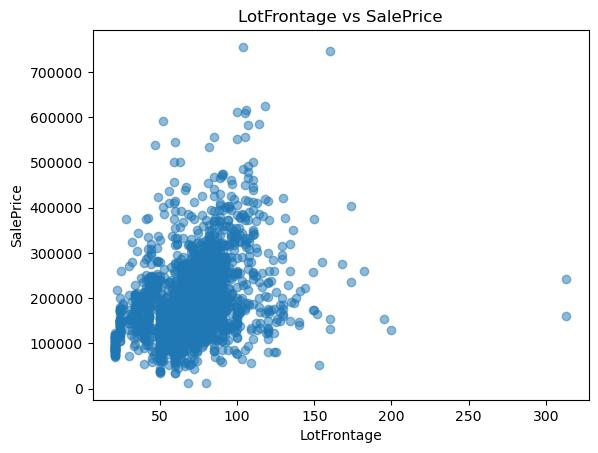

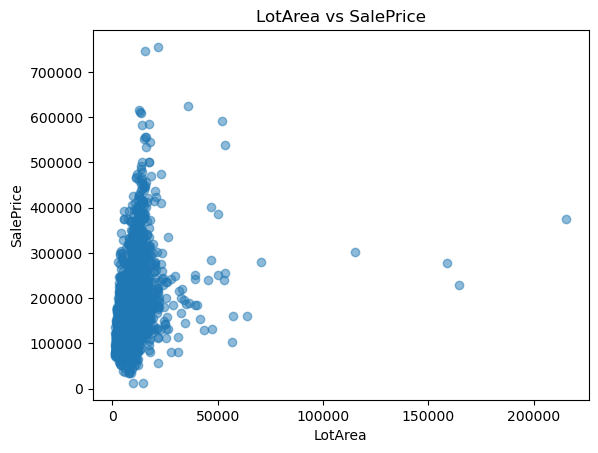

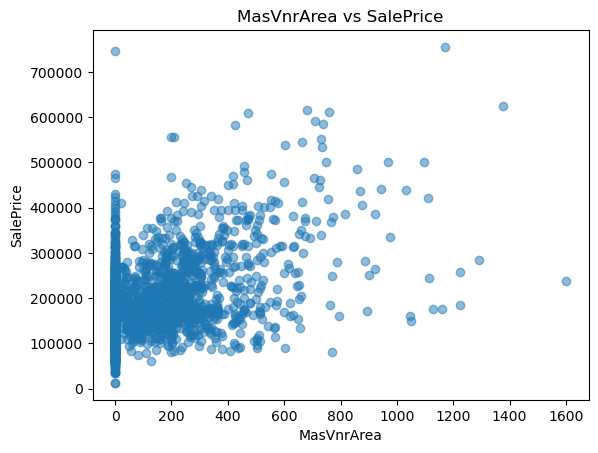

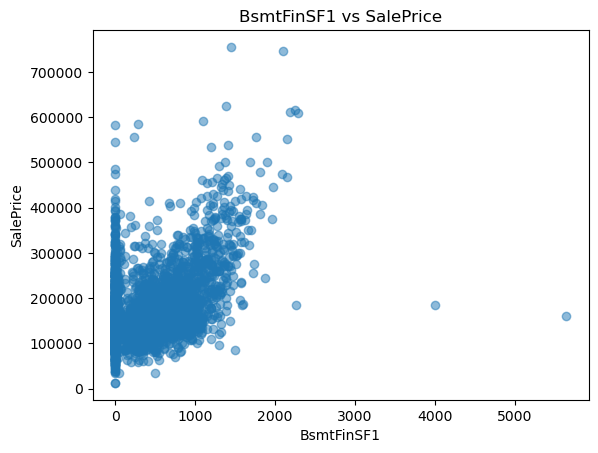

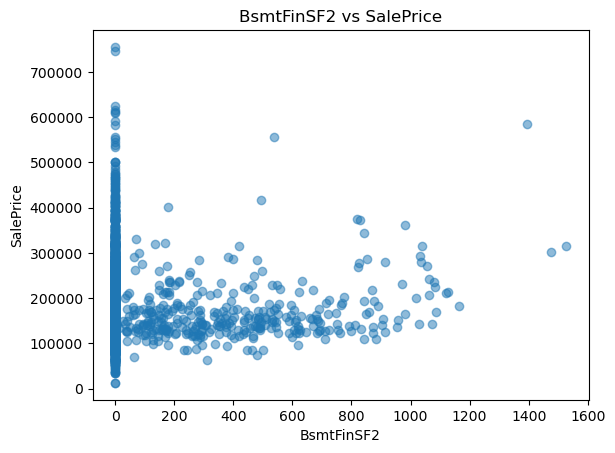

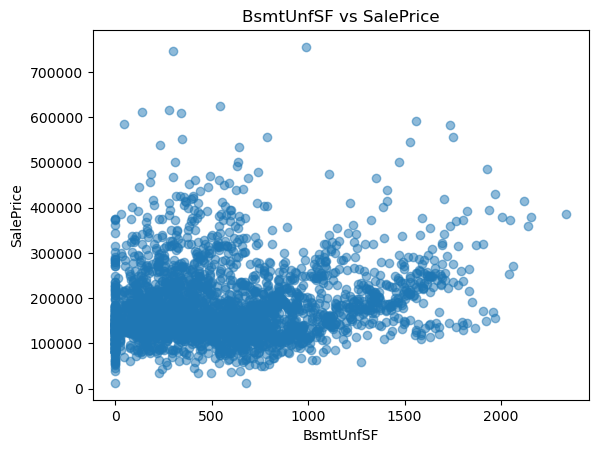

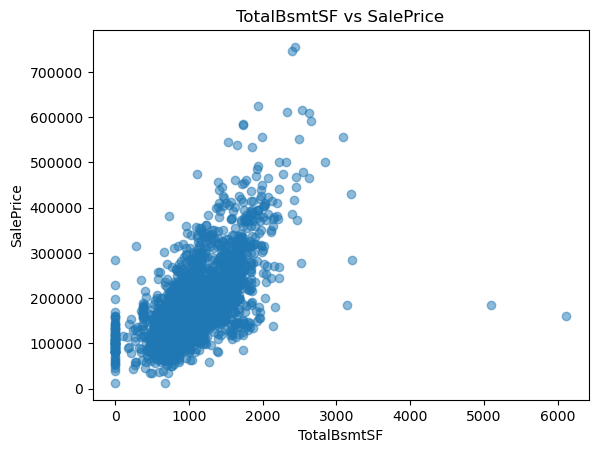

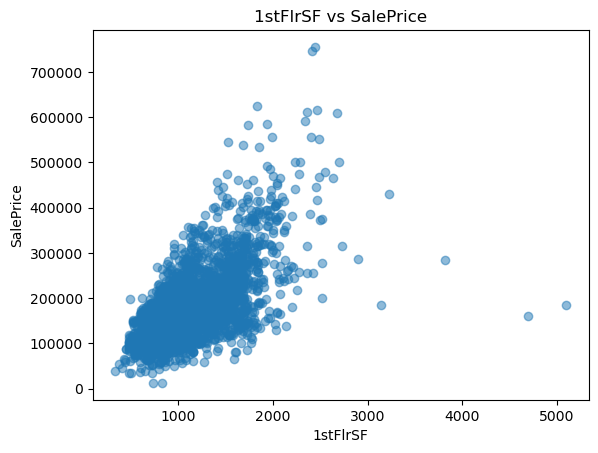

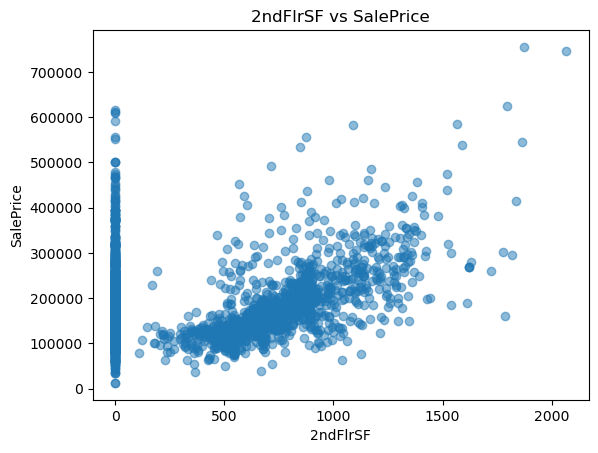

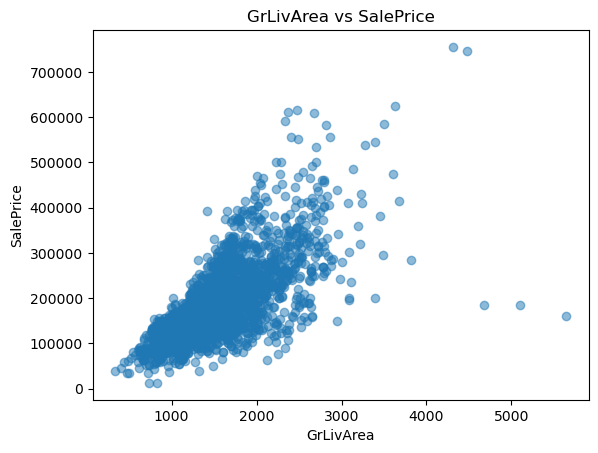

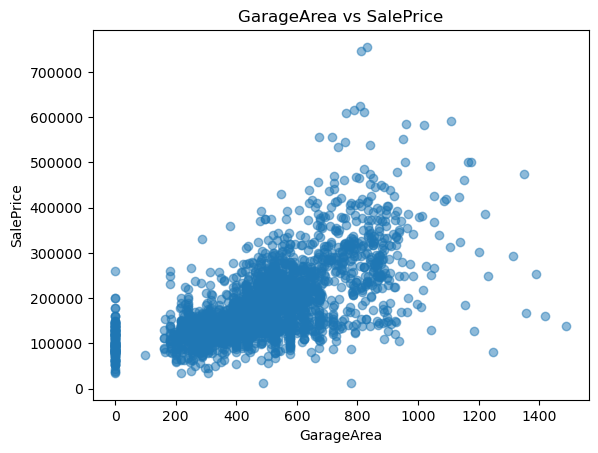

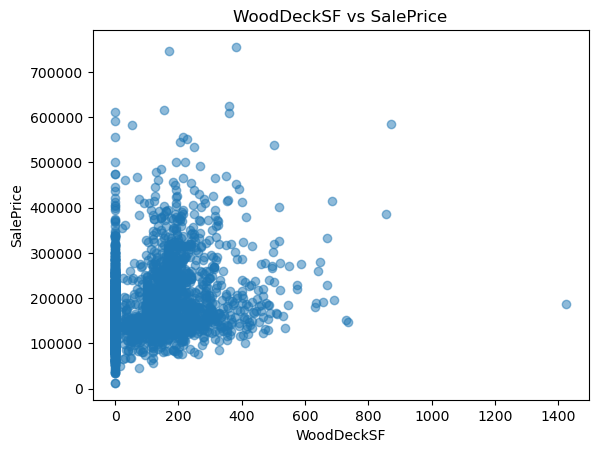

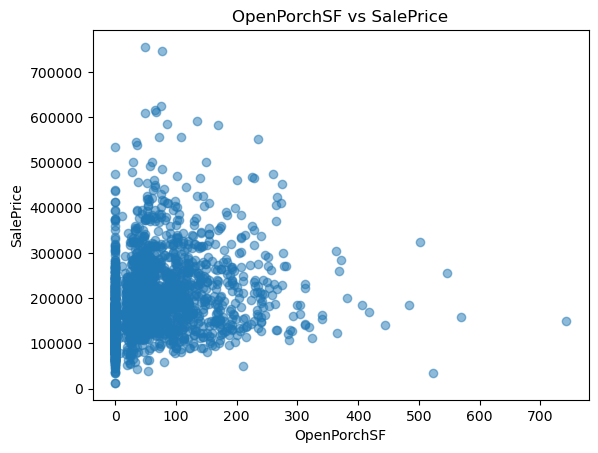

In [19]:
for col in outlier_cols:
    plt.scatter(df[col], df['SalePrice'], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.title(f'{col} vs SalePrice')
    plt.show()

In [20]:
df = df[~((df['GrLivArea'] > 4000) & (df['SalePrice'] < 200000))]

def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ['TotalBsmtSF', 'GarageArea', 'LotArea', '1stFlrSF']:
    df = remove_outliers_iqr(df, col)

print(f'Rows remaining: {len(df)}')

Rows remaining: 2642


#### Scatter Plots AFTER Outlier Treatment

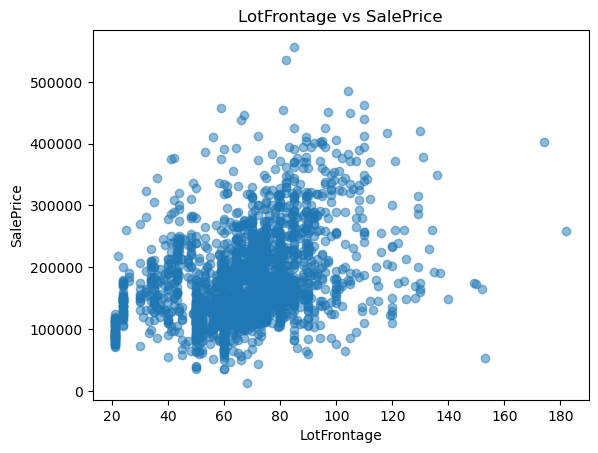

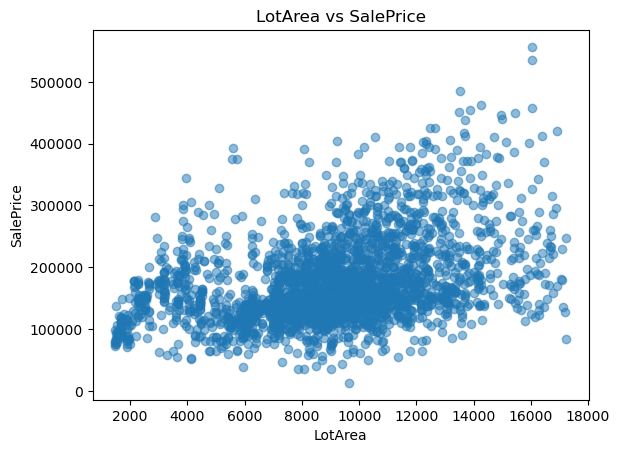

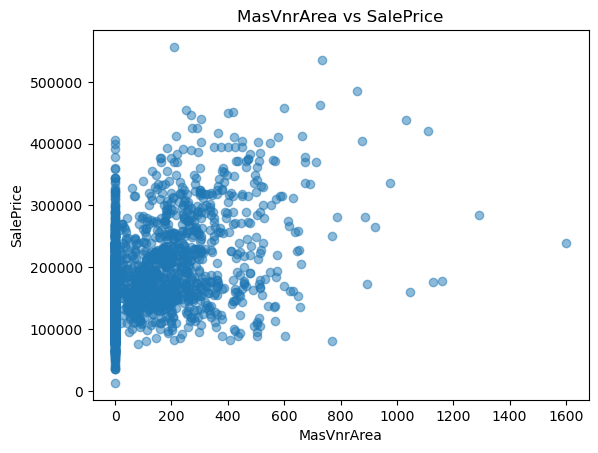

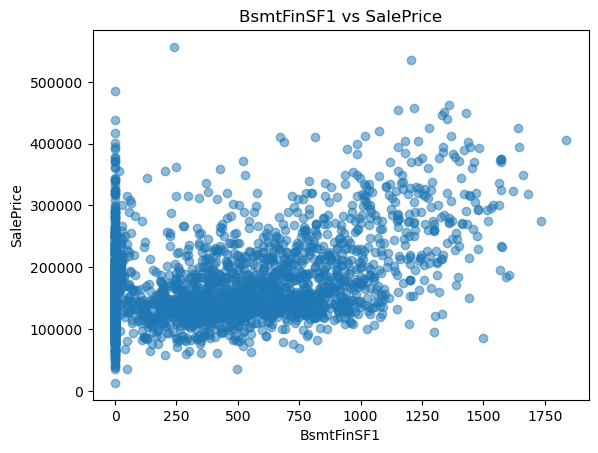

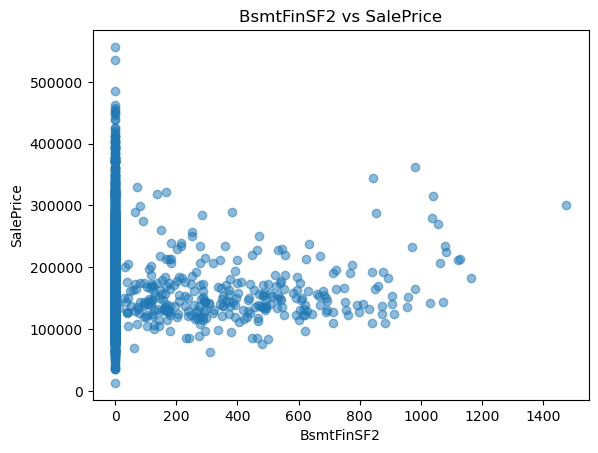

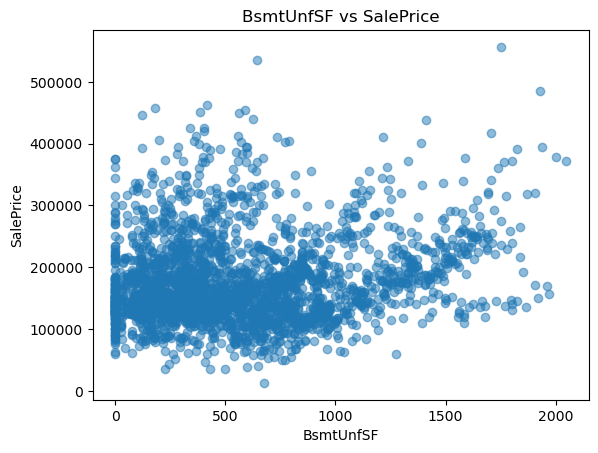

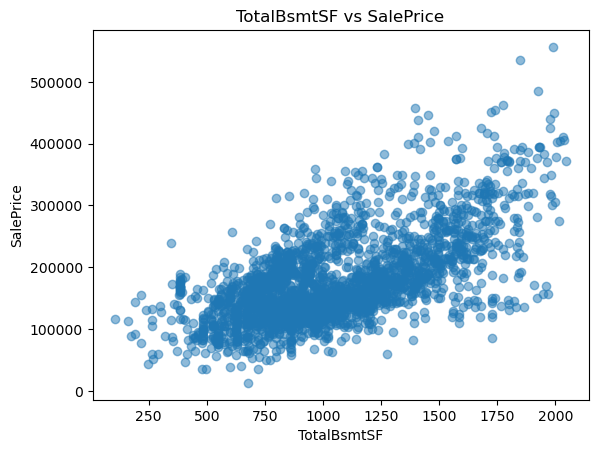

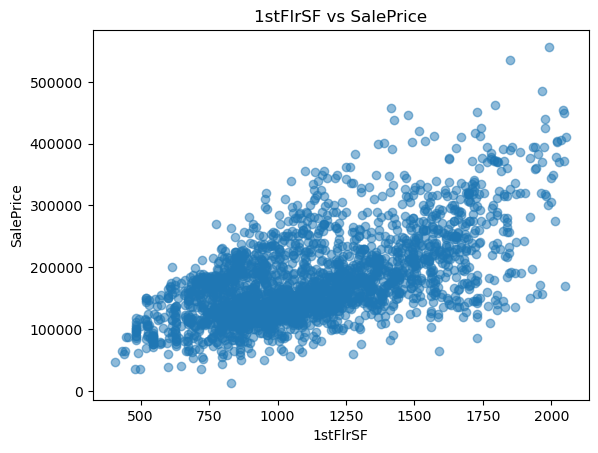

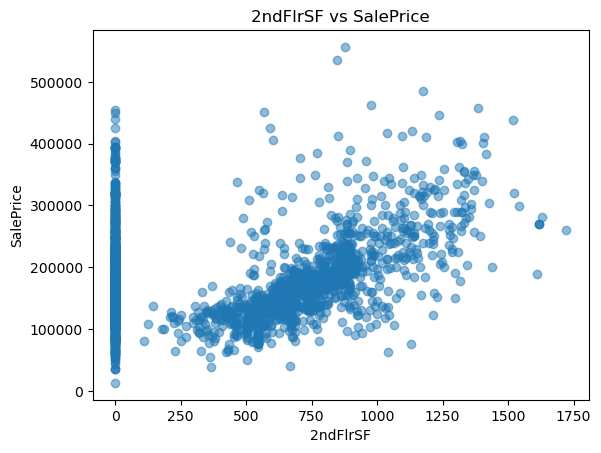

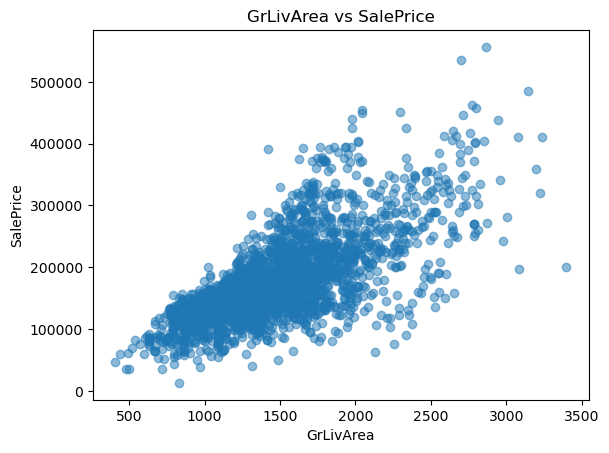

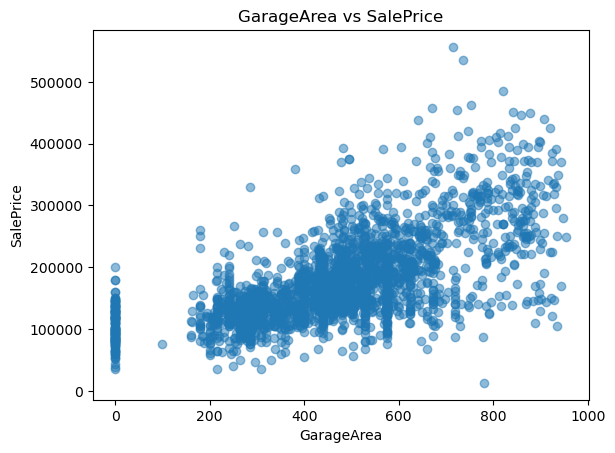

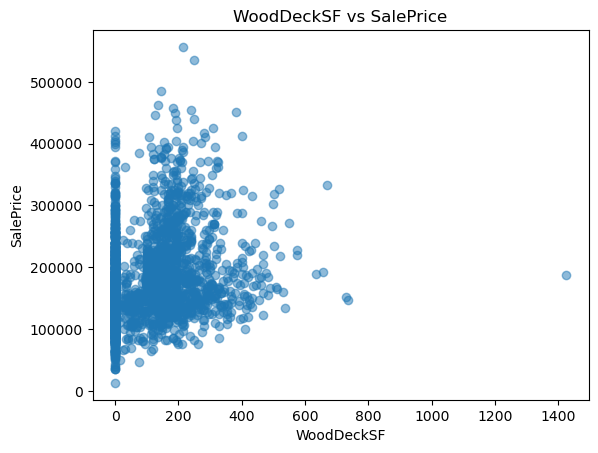

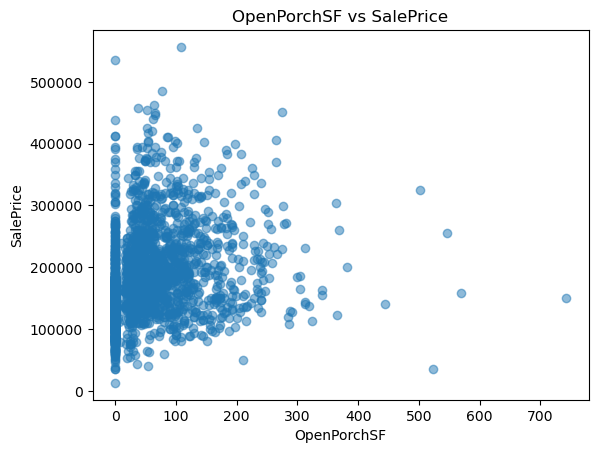

In [21]:
for col in outlier_cols:
    plt.scatter(df[col], df['SalePrice'], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.title(f'{col} vs SalePrice')
    plt.show()

### Outlier Treatment
Outlier treatment is applied selectively based on **scatter plot analysis** and
**domain knowledge** of the Ames Housing dataset. Not all extreme values require
removal — high values in features such as `WoodDeckSF` or `OpenPorchSF` reflect
larger, higher-value properties and are considered valid observations.

Outliers were not removed solely based on statistical thresholds. Each candidate
observation was evaluated based on its **relationship with the target variable (`SalePrice`)**.

**Decision Criteria:**
- Observations were removed only if they were:
  - **Statistically extreme** (identified via scatter plots or IQR), and  
  - **Contextually inconsistent** with the expected relationship between the feature and `SalePrice`

- Observations were retained if they:
  - Represented **legitimate high-value properties**, even if extreme  
  - Followed a **reasonable trend with the target variable**

**Key Principle:**
- Extreme values are not inherently outliers  
- Only those that **violate both statistical and contextual expectations** are treated as anomalies

---

The following features were identified as containing **genuine anomalies**:

- **`GrLivArea`**:
  - Two well-documented observations with above-ground living area exceeding
    4000 sqft but unusually low sale prices  
  - Likely represent partial sales or data entry inconsistencies  
  - Removed using a **manual threshold filter**

- **`TotalBsmtSF`**:
  - One observation with an abnormally large basement (~6000 sqft)  
  - Falls significantly outside the general distribution  
  - Removed using the **IQR method**

- **`GarageArea`**:
  - One observation with a disproportionately large garage area relative to
    its sale price  
  - Removed using the **IQR method**

- **`LotArea`**:
  - A small number of extremely large lots (>100,000 sqft)  
  - Values are orders of magnitude higher than the typical range  
  - Removed using the **IQR method**

- **`1stFlrSF`**:
  - One extreme value aligned with the `GrLivArea` anomaly  
  - Removed using the **IQR method**

---

All remaining numerical features exhibit variability consistent with real-world
housing characteristics and are retained without modification.

**Rationale:**
- Only observations that are **statistically extreme and contextually inconsistent**
  are removed  
- Legitimate high-value properties are preserved to maintain dataset integrity

## 6. Encoding Categorical Features

With numerical preprocessing complete, the final step is to convert categorical features into a format suitable for machine learning models. Since most models cannot directly handle string-based inputs, encoding is required before training.

### Identifying Categorical Features

The dataset contains two types of categorical features, each requiring a different approach:

- **Ordinal features** — categories with a meaningful order  
  (e.g., `ExterQual`: Po < Fa < TA < Gd < Ex)
- **Nominal features** — categories without any inherent order  
  (e.g., `Neighborhood`, `GarageType`, `SaleCondition`)

Choosing the correct encoding strategy is important:
- One-hot encoding ordinal features removes useful ranking information  
- Label encoding nominal features introduces artificial ordering  

### Strategy 1: Ordinal Encoding

Ordinal features are encoded using manually defined mappings that preserve their natural ranking. This allows the model to interpret differences between categories meaningfully instead of treating them as unrelated values.

This approach is applied to:
- Quality and condition features (`ExterQual`, `BsmtQual`, `KitchenQual`, `FireplaceQu`, `GarageQual`, etc.)
- Basement and garage-related ratings (`BsmtExposure`, `BsmtFinType1`, `GarageFinish`)
- Structural ordinal features (`LotShape`, `LandSlope`, `Utilities`, `Functional`, `PavedDrive`)

Missing categories, previously imputed as `"None"`, are mapped to `0`, representing the absence of the feature. This keeps the encoding consistent with earlier preprocessing steps.

### Strategy 2: One-Hot Encoding

Nominal features are encoded using `pd.get_dummies` with `drop_first=True` to avoid multicollinearity caused by redundant dummy variables.

This approach is applied to:
- Location-based features (`Neighborhood`, `MSZoning`)
- Structural descriptors (`BldgType`, `HouseStyle`, `Foundation`)
- Material features (`Exterior1st`, `Exterior2nd`, `RoofMatl`)
- Sale and time-related features (`SaleType`, `SaleCondition`, `MoSold`)

Each category is converted into a binary indicator, allowing the model to treat them as distinct groups without assuming any order.

### Verification

After encoding, the dataset is validated to ensure:
- No object-type columns remain  
- No null values were introduced during mapping  
- The final dataset structure is consistent and ready for modeling

In [22]:
ordinal_mappings = {
    'ExterQual':    {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'ExterCond':    {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'BsmtQual':     {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'BsmtCond':     {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'BsmtExposure': {'None':0,'No':1,'Mn':2,'Av':3,'Gd':4},
    'BsmtFinType1': {'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6},
    'BsmtFinType2': {'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6},
    'HeatingQC':    {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'KitchenQual':  {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'FireplaceQu':  {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'GarageFinish': {'None':0,'Unf':1,'RFn':2,'Fin':3},
    'GarageQual':   {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'GarageCond':   {'None':0,'Po':1,'Fa':2,'TA':3,'Gd':4,'Ex':5},
    'PoolQC':       {'None':0,'Fa':1,'TA':2,'Gd':3,'Ex':4},
    'Fence':        {'None':0,'MnWw':1,'GdWo':2,'MnPrv':3,'GdPrv':4},
    'Functional':   {'Sal':1,'Sev':2,'Maj2':3,'Maj1':4,'Mod':5,'Min2':6,'Min1':7,'Typ':8},
    'LotShape':     {'IR3':1,'IR2':2,'IR1':3,'Reg':4},
    'LandSlope':    {'Sev':1,'Mod':2,'Gtl':3},
    'Utilities':    {'ELO':1,'NoSeWa':2,'NoSewr':3,'AllPub':4},
    'PavedDrive':   {'N':0,'P':1,'Y':2},
    'CentralAir':   {'N':0,'Y':1},
}

for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)

In [23]:
nominal_cols = ['MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig',
                'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
                'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
                'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating',
                'Electrical', 'GarageType', 'MiscFeature', 'MoSold',
                'SaleType', 'SaleCondition']

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in nominal_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [24]:
print(df.shape)
print(df.select_dtypes(include='object').columns.tolist())  # should be empty
print(df.isnull().sum().sum())  # should be 0

(2642, 81)
[]
0


## 7. Save Cleaned Dataset

At this stage, the preprocessing pipeline is complete and the dataset has been 
transformed into a clean, structured format ready for modeling.

### Summary of Steps Performed

| Step | Action |
|---|---|
| **1. Fix Data Types** | Converted relevant float features (`GarageYrBlt`, `LotFrontage`, `MasVnrArea`) to integer form after handling missing values; treated `MoSold` as a categorical feature |
| **2. Handle Missing Values** | Imputed feature-absence columns with `"None"`; used neighborhood-based median for `LotFrontage`, `YearBuilt` for `GarageYrBlt`, and mode for `Electrical` |
| **3. Handle Outliers** | Removed two known `GrLivArea` anomalies manually; applied selective IQR-based removal for `TotalBsmtSF`, `GarageArea`, `LotArea`, and `1stFlrSF` |
| **4. Fix Skewed Features** | Applied `log1p` transformation to highly skewed features and `sqrt` transformation to moderately skewed basement-related features (`BsmtUnfSF`, `BsmtFinSF1`, `TotalBsmtSF`) |
| **5. Feature Engineering** | Created new features including area aggregates, total bathrooms, interaction terms, binary indicators, and age-based variables |
| **6. Encoding** | Applied ordinal mapping with defined rankings and one-hot encoding for nominal features using `drop_first=True` |

### Final Dataset

- **Rows:** 1308 (after outlier removal from original 1460)  
- **Missing values:** 0  
- **Feature types:** All numerical (fully encoded and model-ready)  

The processed dataset is saved to `../data/processed_train.csv` and will be used 
directly in the modeling stage.

In [25]:
# drop Id
df = df.drop(columns=['Id'])

# convert booleans to int
bool_cols = df.select_dtypes(bool).columns
df[bool_cols] = df[bool_cols].astype(int)

# save
df.to_csv('../data/processed_ames_for_trees.csv', index=False)
print(df.shape)

(2642, 80)
